# EDA profesional de `gold-features.csv`

**Autor: Jose Melo**


Este notebook realiza un análisis exploratorio profesional del dataset `gold-features.csv`, orientado a entender la calidad de los datos, sus distribuciones, anomalas, relaciones entre variables y utilidad potencial para un modelo de Machine Learning.

Conclusiones iniciales observadas en la revisión local del archivo:

- El dataset contiene **2.865 registros y 26 columnas**, con observaciones temporales desde **2015-01-30 hasta 2026-06-26**.
- No se observan valores nulos ni duplicados exactos en el archivo analizado.
- La variable `target_binary` esta razonablemente balanceada: aproximadamente **52,9% clase 1** y **47,1% clase 0**.
- `target_multiclass` presenta mas concentración en la clase neutral `0`, cerca de **49,6%**, frente a **27,7%** para `1` y **22,8%** para `-1`.
- Las correlaciones lineales simples con los targets son bajas, lo que sugiere que el problema puede requerir modelos capaces de capturar relaciones no lineales, interacciones y dependencia temporal.
- Hay valores extremos relevantes en volumen, volatilidad, MACD, rangos diarios y retornos. En series financieras, estos puntos no deben eliminarse automaticamente: pueden representar eventos de mercado utiles para el modelo.

## Contexto & Methods

El objetivo es documentar el estado del dataset y producir evidencia ?til para las siguientes fases de modelado: limpieza, selecci?n de variables, validación temporal, tratamiento de outliers y definición de riesgos de leakage.

### Key Assumptions

- Cada fila representa una observación diaria o de mercado ordenada temporalmente.
- `target_binary` y `target_multiclass` son variables objetivo ya construidas para modelado supervisado.
- Las variables con prefijos `gold`, `dxy`, `vix` y `tnx` representan señales de mercado y/o features técnicas.
- En un problema financiero temporal, la validación del modelo debería ser cronológica, no aleatoria.

## 1. Setup del entorno

Importamos las librerías necesarias para manipulación de datos, análisis numérico, visualización y presentación de tablas. También fijamos una configuración visual consistente para que las gráficas sean legibles en Google Colab y en Jupyter local.

In [37]:
# Manipulacion y calculo numerico
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Presentacion en notebook
from IPython.display import display

# Configuracion general
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 2. Carga de datos

Cargamos el CSV desde varias rutas posibles para que el notebook funcione tanto dentro del repositorio como en Google Colab. Después convertimos `Date` a formato fecha y ordenamos el dataset temporalmente, una práctica importante cuando se trabaja con series financieras.

In [38]:
# Rutas candidatas para ejecucion local o en Google Colab.
DATA_PATH_CANDIDATES = [
    Path("../data/processed/gold-features.csv"),
    Path("data/processed/gold-features.csv"),
    Path("/content/gold-features.csv"),
]

data_path = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "No se encontró gold-features.csv. Ajusta DATA_PATH_CANDIDATES o sube el archivo a Colab."
    )

# Carga del dataset.
gold_df = pd.read_csv(data_path)

# Normalizacion de fecha y orden temporal.
gold_df["Date"] = pd.to_datetime(gold_df["Date"], errors="coerce")
gold_df = gold_df.sort_values("Date").reset_index(drop=True)

print(f"Archivo cargado desde: {data_path}")
print(f"Dimension del dataset: {gold_df.shape[0]:,} filas x {gold_df.shape[1]:,} columnas")
display(gold_df.head())

Archivo cargado desde: ..\data\processed\gold-features.csv
Dimension del dataset: 2,865 filas x 26 columnas


,Date,gold_volume,gold_return,dxy_return,vix_return,tnx_return,gold_daily_range,dxy_daily_range,vix_daily_range,tnx_daily_range,gold_open_close_return,dxy_open_close_return,vix_open_close_return,tnx_open_close_return,gold_ma_5,gold_ma_20,gold_close_vs_ma_5,gold_close_vs_ma_20,gold_rsi_14,gold_macd,gold_macd_signal,gold_volatility_14,gold_return_lag_1,gold_return_lag_2,target_binary,target_multiclass
0,2015-01-30,8626.0000,0.0190,0.0002,0.1178,-0.0434,0.0217,0.0052,0.1453,0.0329,0.0163,0.0015,0.0366,-0.0159,1278.0200,1252.9250,0.0004,0.0204,67.3322,22.2847,22.9106,0.0128,-0.0243,-0.0045,0,0
1,2015-02-02,1654.0000,-0.0018,-0.0032,-0.0734,-0.0012,0.0141,0.0054,0.1656,0.0346,-0.0062,-0.0036,-0.0699,-0.0006,1277.3800,1257.4350,-0.0009,0.0149,63.1103,21.1039,22.5493,0.0125,0.0190,-0.0243,0,-1
2,2015-02-03,2380.0000,-0.0129,-0.0095,-0.1081,0.0640,0.0231,0.0153,0.0918,0.0396,-0.0108,-0.0103,-0.0587,0.0367,1270.9800,1260.2250,-0.0089,-0.0004,57.0243,18.6221,21.7638,0.0132,-0.0018,0.0190,1,0
3,2015-02-04,668.0000,0.0033,0.0042,0.0577,0.0096,0.0117,0.0098,0.0875,0.0346,0.0014,0.0027,0.0286,-0.0132,1266.5600,1262.4500,-0.0022,0.0011,57.9546,16.7924,20.7696,0.0132,-0.0129,-0.0018,0,0
4,2015-02-05,133.0000,-0.0014,0.0076,-0.0807,0.0100,0.0116,0.0132,0.0440,0.0228,-0.0077,0.0118,-0.0254,0.0083,1268.0400,1265.0200,-0.0048,-0.0024,49.1363,15.0240,19.6204,0.0114,0.0033,-0.0129,0,-1


## 3. Estructura general del dataset

Revisamos tipos de datos, columnas disponibles, rango temporal y una muestra inicial. Este paso permite validar si el dataset está listo para análisis o si necesita correcciones estructurales antes de modelar.

In [39]:
# Resumen estructural del dataset.
structure_summary = pd.DataFrame({
    "column": gold_df.columns,
    "dtype": gold_df.dtypes.astype(str).values,
    "non_null": gold_df.notna().sum().values,
    "null_count": gold_df.isna().sum().values,
    "unique_values": gold_df.nunique(dropna=False).values,
})

print("Rango temporal:")
print(f"Desde {gold_df['Date'].min().date()} hasta {gold_df['Date'].max().date()}")
print(f"Fechas ordenadas de forma creciente: {gold_df['Date'].is_monotonic_increasing}")

display(structure_summary)

Rango temporal:
Desde 2015-01-30 hasta 2026-06-26
Fechas ordenadas de forma creciente: True


,column,dtype,non_null,null_count,unique_values
0,Date,datetime64[us],2865,0,2865
1,gold_volume,float64,2865,0,1166
2,gold_return,float64,2865,0,2852
3,dxy_return,float64,2865,0,2821
4,vix_return,float64,2865,0,2851
5,tnx_return,float64,2865,0,2805
6,gold_daily_range,float64,2865,0,2718
7,dxy_daily_range,float64,2865,0,2858
8,vix_daily_range,float64,2865,0,2860
9,tnx_daily_range,float64,2865,0,2840


## 4. Calidad de datos: nulos, duplicados y fechas

Validamos problemas básicos de calidad: valores nulos, duplicados exactos, fechas duplicadas y fechas no parseadas. Estos controles son críticos porque errores silenciosos en datos temporales pueden contaminar el entrenamiento y la validación del modelo.

In [40]:
# Chequeos de calidad básicos.
quality_checks = {
    "rows": len(gold_df),
    "columns": gold_df.shape[1],
    "duplicated_rows": int(gold_df.duplicated().sum()),
    "duplicated_dates": int(gold_df["Date"].duplicated().sum()),
    "missing_dates_after_parse": int(gold_df["Date"].isna().sum()),
}

missing_summary = (
    gold_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda table: 100 * table["missing_count"] / len(gold_df))
    .sort_values("missing_count", ascending=False)
)

print("Resumen de calidad:")
display(pd.Series(quality_checks).to_frame("value"))

print("Valores nulos por columna:")
display(missing_summary)

Resumen de calidad:


,value
rows,2865
columns,26
duplicated_rows,0
duplicated_dates,0
missing_dates_after_parse,0


Valores nulos por columna:


,missing_count,missing_pct
Date,0,0.0000
gold_volume,0,0.0000
gold_return,0,0.0000
dxy_return,0,0.0000
vix_return,0,0.0000
tnx_return,0,0.0000
gold_daily_range,0,0.0000
dxy_daily_range,0,0.0000
vix_daily_range,0,0.0000
tnx_daily_range,0,0.0000


## 5. Separación de variables para análisis

Clasificamos columnas por tipo y rol analático. Separar fecha, targets y features evita mezclar variables objetivo dentro de análisis de predictors y reduce el riesgo de leakage durante exploración y modelado.

In [41]:
# Identificación explícita de variables clave.
target_columns = ["target_binary", "target_multiclass"]
date_column = "Date"

numeric_columns = gold_df.select_dtypes(include=np.number).columns.tolist()
feature_columns = [column for column in numeric_columns if column not in target_columns]

feature_groups = {
    "gold_features": [column for column in feature_columns if column.startswith("gold")],
    "dxy_features": [column for column in feature_columns if column.startswith("dxy")],
    "vix_features": [column for column in feature_columns if column.startswith("vix")],
    "tnx_features": [column for column in feature_columns if column.startswith("tnx")],
}

print(f"Features numéricas: {len(feature_columns)}")
print(f"Targets: {target_columns}")

for group_name, columns in feature_groups.items():
    print(f"{group_name}: {len(columns)} columnas")
    print(columns)

Features numéricas: 23
Targets: ['target_binary', 'target_multiclass']
gold_features: 14 columnas
['gold_volume', 'gold_return', 'gold_daily_range', 'gold_open_close_return', 'gold_ma_5', 'gold_ma_20', 'gold_close_vs_ma_5', 'gold_close_vs_ma_20', 'gold_rsi_14', 'gold_macd', 'gold_macd_signal', 'gold_volatility_14', 'gold_return_lag_1', 'gold_return_lag_2']
dxy_features: 3 columnas
['dxy_return', 'dxy_daily_range', 'dxy_open_close_return']
vix_features: 3 columnas
['vix_return', 'vix_daily_range', 'vix_open_close_return']
tnx_features: 3 columnas
['tnx_return', 'tnx_daily_range', 'tnx_open_close_return']


## 6. Estadística descriptiva

Calculamos medidas de tendencia central, dispersión y percentiles para entender escala, asimetrías y rangos. Esto ayuda a anticipar necesidades de escalado, transformaciones y tratamiento de valores extremos en el pipeline de ML.

In [42]:
# Estadística descriptiva de las features numéricas.
descriptive_stats = gold_df[feature_columns].describe().T

descriptive_stats["missing_count"] = gold_df[feature_columns].isna().sum()
descriptive_stats["missing_pct"] = 100 * descriptive_stats["missing_count"] / len(gold_df)
descriptive_stats["skewness"] = gold_df[feature_columns].skew(numeric_only=True)
descriptive_stats["kurtosis"] = gold_df[feature_columns].kurtosis(numeric_only=True)

display(descriptive_stats.sort_index())

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skewness,kurtosis
dxy_daily_range,2865.0000,0.0063,0.0032,0.0014,0.0042,0.0056,0.0074,0.0348,0,0.0000,2.2430,9.4640
dxy_open_close_return,2865.0000,0.0001,0.0042,-0.0239,-0.0025,0.0002,0.0026,0.0214,0,0.0000,-0.1280,2.0161
dxy_return,2865.0000,0.0000,0.0044,-0.0237,-0.0025,0.0001,0.0026,0.0205,0,0.0000,-0.1446,1.7203
gold_close_vs_ma_20,2865.0000,0.0041,0.0240,-0.1246,-0.0104,0.0034,0.0186,0.1367,0,0.0000,0.0993,2.0694
gold_close_vs_ma_5,2865.0000,0.0008,0.0112,-0.0768,-0.0052,0.0006,0.0072,0.0827,0,0.0000,-0.2699,4.7487
gold_daily_range,2865.0000,0.0100,0.0087,0.0000,0.0047,0.0083,0.0131,0.1377,0,0.0000,3.6146,29.6751
gold_ma_20,2865.0000,1887.9914,869.6072,1068.8550,1275.1250,1730.5100,1960.7350,5119.0450,0,0.0000,1.9070,3.3025
gold_ma_5,2865.0000,1895.7379,878.1645,1060.3400,1278.3400,1732.5800,1970.2400,5212.7199,0,0.0000,1.8890,3.2056
gold_macd,2865.0000,7.7360,28.6560,-152.8623,-6.0485,3.4927,17.2135,227.3740,0,0.0000,1.1491,9.3687
gold_macd_signal,2865.0000,7.9171,26.8028,-108.3070,-5.4024,3.1991,17.0744,170.0768,0,0.0000,1.4067,7.6177


## 7. Distribución de los targets

Analizamos el balance de clases. Un target desbalanceado puede exigir métricas robustas, validación estratificada temporalmente, class weights o técnicas específicas de evaluación.

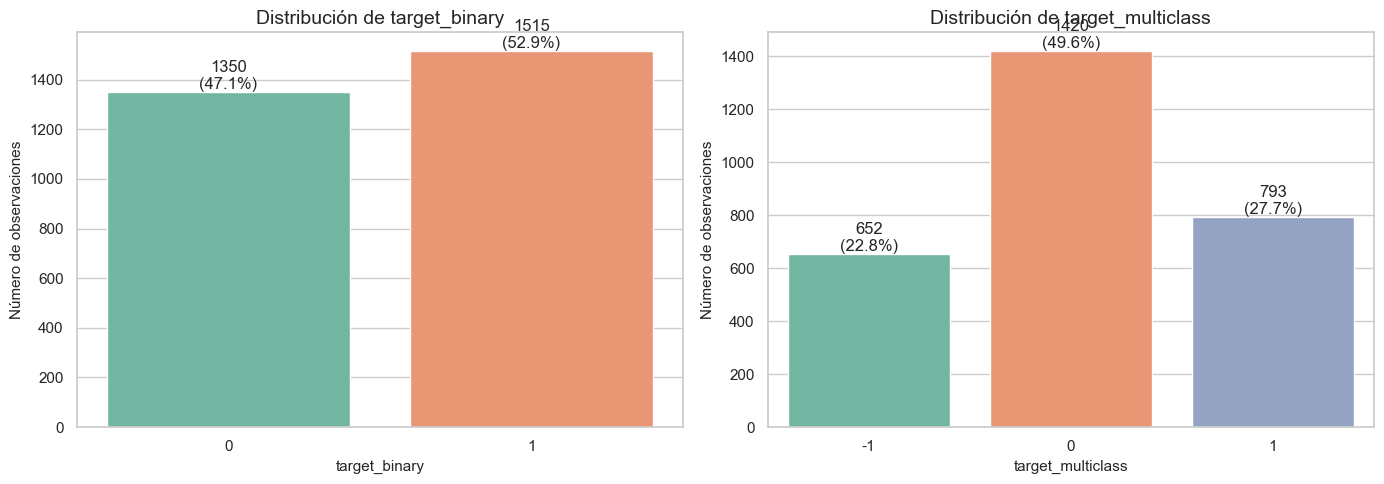

target_binary


,count,percentage
target_binary,,
0,1350,47.1200
1,1515,52.8800


target_multiclass


,count,percentage
target_multiclass,,
-1,652,22.7600
0,1420,49.5600
1,793,27.6800


In [43]:
# Distribución absoluta y porcentual de los targets.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_tables = {}
for axis, target in zip(axes, target_columns):
    counts = gold_df[target].value_counts().sort_index()
    percentages = 100 * gold_df[target].value_counts(normalize=True).sort_index()
    target_tables[target] = pd.DataFrame({"count": counts, "percentage": percentages.round(2)})

    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axis, palette="Set2")
    axis.set_title(f"Distribución de {target}")
    axis.set_xlabel(target)
    axis.set_ylabel("Número de observaciones")

    for position, value in enumerate(counts.values):
        axis.text(position, value, f"{value}\n({percentages.iloc[position]:.1f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

for target, table in target_tables.items():
    print(target)
    display(table)

## 8. Distribuciones de features principales

Visualizamos histogramas de las variables numéricas para detectar colas pesadas, concentración cerca de cero, asimetrías y posibles transformaciones necesarias. En datos financieros es habitual observar distribuciones no normales y eventos extremos.

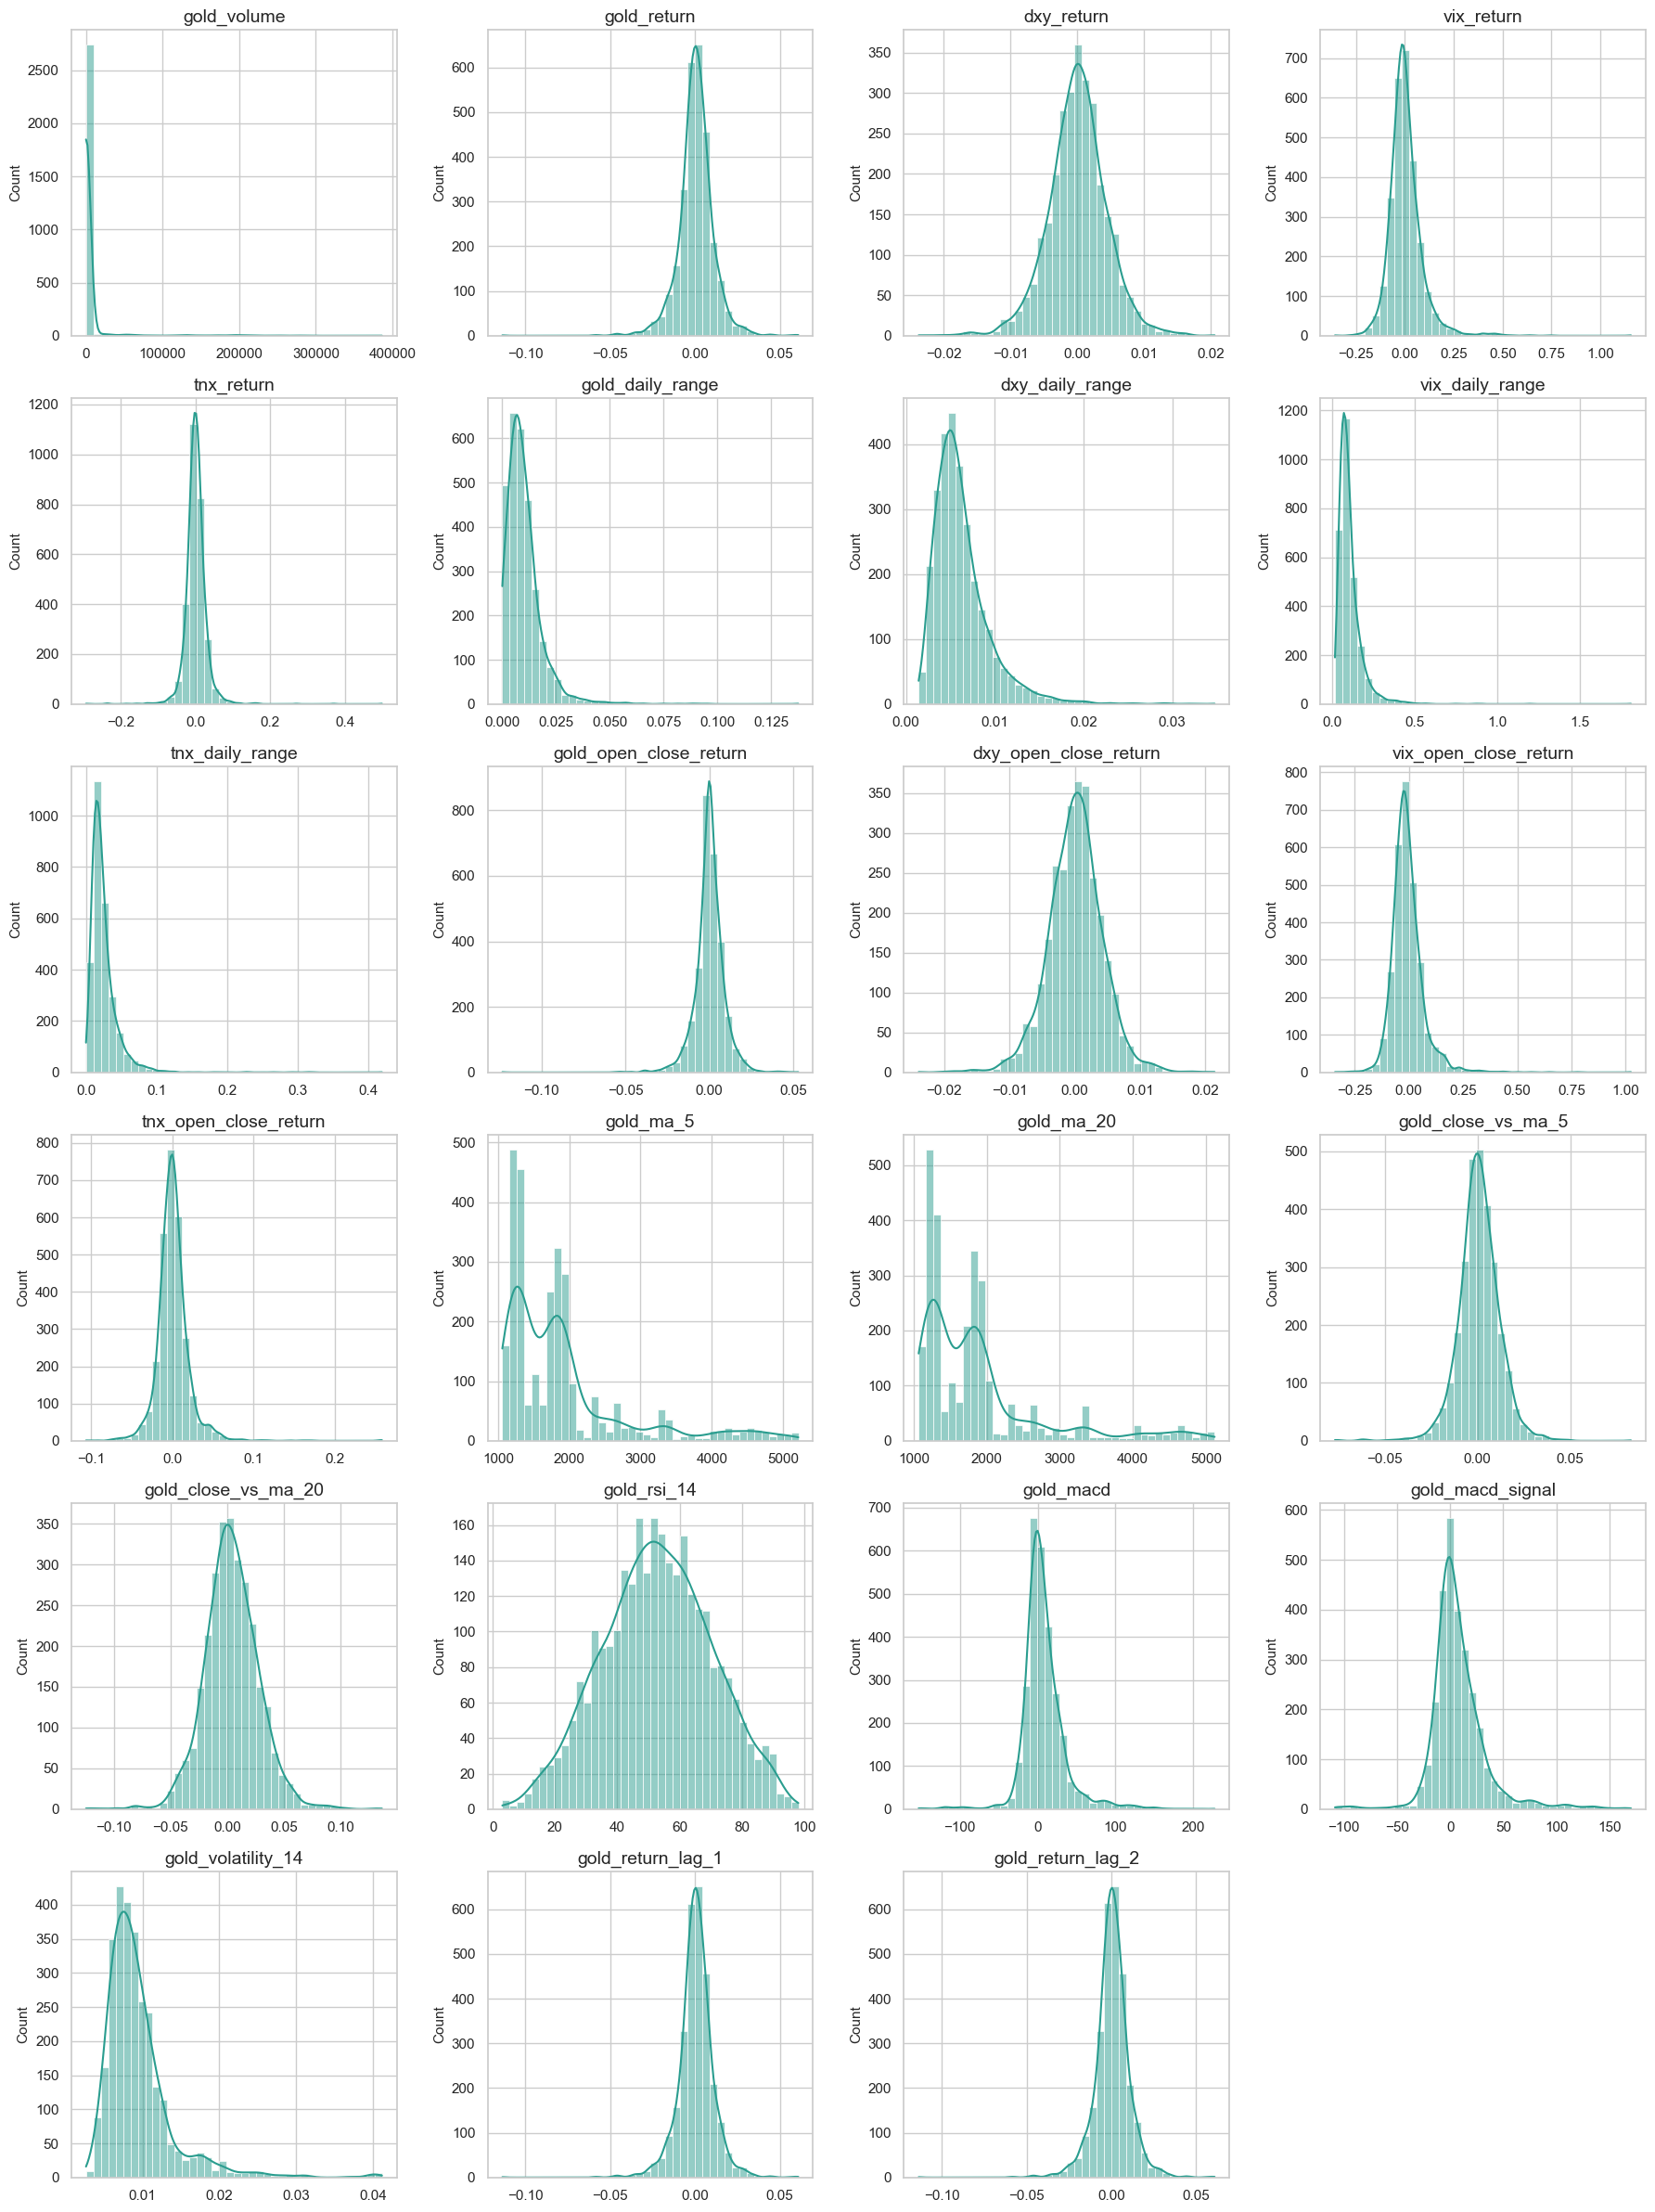

In [44]:
# Histogramas compactos de todas las features numéricas.
number_of_features = len(feature_columns)
columns_per_row = 4
rows = int(np.ceil(number_of_features / columns_per_row))

fig, axes = plt.subplots(rows, columns_per_row, figsize=(18, 4 * rows))
axes = axes.flatten()

for index, column in enumerate(feature_columns):
    sns.histplot(gold_df[column], kde=True, bins=40, ax=axes[index], color="#2a9d8f")
    axes[index].set_title(column)
    axes[index].set_xlabel("")

# Ocultamos ejes sobrantes si el número de variables no completa la cuadrícula.
for empty_axis in axes[number_of_features:]:
    empty_axis.set_visible(False)

plt.tight_layout()
plt.show()

## 9. Boxplots y detección inicial de anomalías

Usamos el criterio IQR para identificar valores extremos por variable. En este contexto los outliers no son automáticamente errores: pueden representar shocks de mercado y deben evaluarse antes de eliminarlos o caparlos.

Variables con mayor número de valores extremos por criterio IQR:


,outlier_count,outlier_pct
gold_volume,343,11.9721
gold_ma_5,320,11.1693
gold_ma_20,312,10.8901
gold_macd,201,7.0157
gold_volatility_14,195,6.8063
gold_macd_signal,193,6.7365
gold_open_close_return,190,6.6318
tnx_open_close_return,187,6.5271
tnx_daily_range,179,6.2478
vix_daily_range,171,5.9686


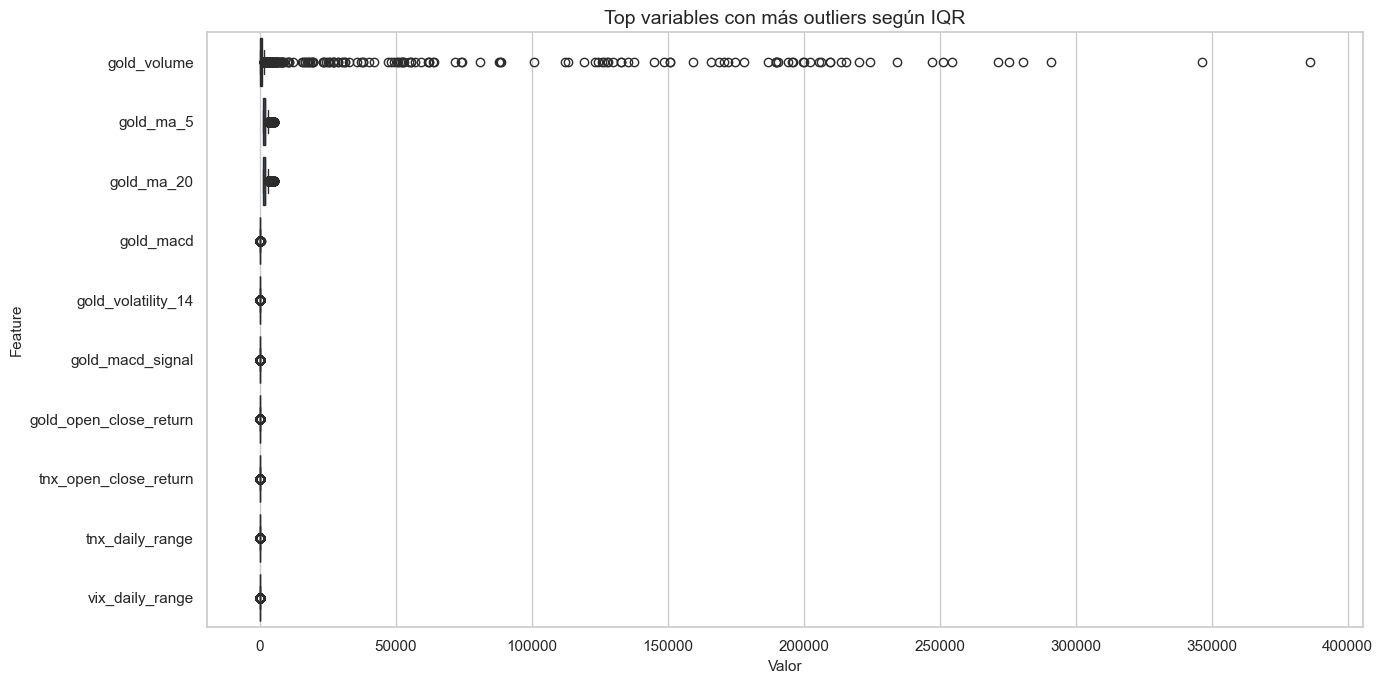

In [45]:
# Cálculo de outliers mediante rango intercuartílico (IQR).
q1 = gold_df[feature_columns].quantile(0.25)
q3 = gold_df[feature_columns].quantile(0.75)
iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_mask = (gold_df[feature_columns] < lower_bounds) | (gold_df[feature_columns] > upper_bounds)
outlier_summary = (
    outlier_mask.sum()
    .rename("outlier_count")
    .to_frame()
    .assign(outlier_pct=lambda table: 100 * table["outlier_count"] / len(gold_df))
    .sort_values("outlier_count", ascending=False)
)

print("Variables con mayor número de valores extremos por criterio IQR:")
display(outlier_summary.head(15))

# Boxplots de las variables más afectadas por outliers.
top_outlier_columns = outlier_summary.head(10).index.tolist()
plt.figure(figsize=(14, 7))
sns.boxplot(data=gold_df[top_outlier_columns], orient="h", palette="viridis")
plt.title("Top variables con más outliers según IQR")
plt.xlabel("Valor")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Inspección de eventos extremos

Mostramos filas asociadas a los valores más extremos de variables críticas. Esta tabla sirve para revisar si las anomalías parecen errores de captura o eventos financieros plausibles.

In [46]:
# Seleccionamos variables especialmente relevantes para inspección manual.
critical_columns = [
    "gold_volume",
    "gold_return",
    "vix_return",
    "tnx_return",
    "gold_volatility_14",
]
critical_columns = [column for column in critical_columns if column in gold_df.columns]

extreme_rows = []
for column in critical_columns:
    # Tomamos los máximos absolutos para detectar shocks positivos y negativos.
    selected = gold_df.loc[gold_df[column].abs().nlargest(5).index, ["Date", column, *target_columns]].copy()
    selected.insert(1, "feature_checked", column)
    selected = selected.rename(columns={column: "feature_value"})
    extreme_rows.append(selected)

extreme_events = pd.concat(extreme_rows, ignore_index=True).sort_values(
    ["feature_checked", "feature_value"], ascending=[True, False]
)

display(extreme_events)

,Date,feature_checked,feature_value,target_binary,target_multiclass
6,2026-02-03,gold_return,0.0608,1,0
7,2020-03-24,gold_return,0.0595,0,-1
9,2025-10-21,gold_return,-0.0574,0,-1
8,2026-03-19,gold_return,-0.0591,0,-1
5,2026-01-30,gold_return,-0.1137,0,-1
20,2026-02-17,gold_volatility_14,0.0412,1,1
21,2026-02-12,gold_volatility_14,0.0405,1,1
22,2026-02-06,gold_volatility_14,0.0405,1,1
23,2026-02-13,gold_volatility_14,0.0405,0,-1
24,2026-02-05,gold_volatility_14,0.0405,1,1


## 11. Evolución temporal de variables clave

Graficamos la evolución temporal de retornos, volatilidad, volumen y señales técnicas. Este paso ayuda a detectar cambios de régimen, periodos de estrés y posibles diferencias entre entrenamiento y validación futura.

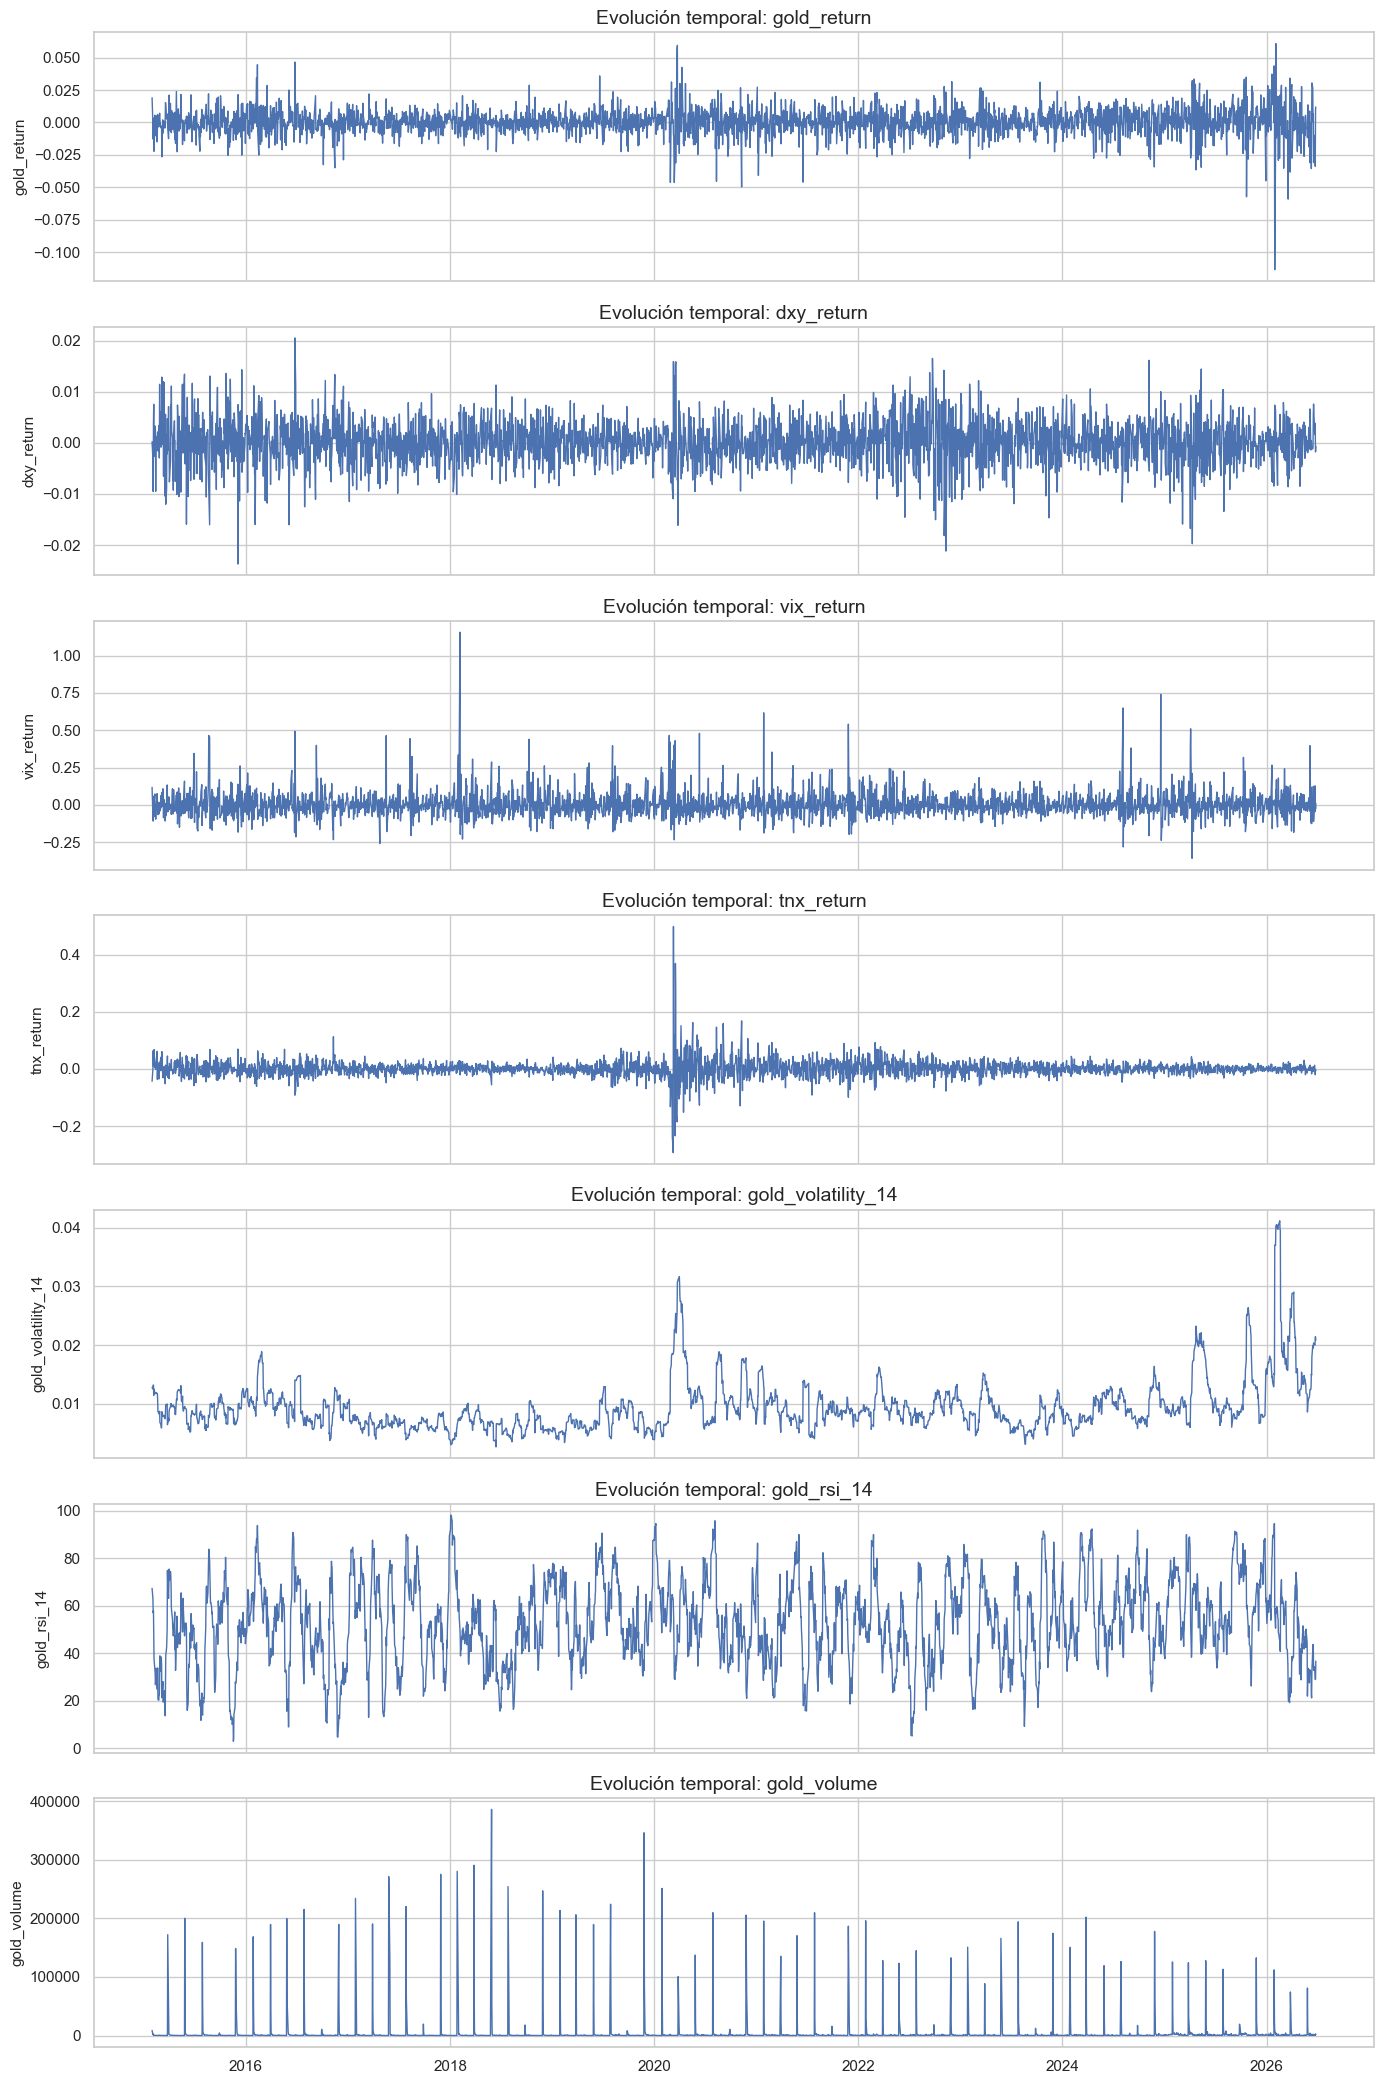

In [47]:
# Variables representativas para observar patrones temporales.
time_series_columns = [
    "gold_return",
    "dxy_return",
    "vix_return",
    "tnx_return",
    "gold_volatility_14",
    "gold_rsi_14",
    "gold_volume",
]
time_series_columns = [column for column in time_series_columns if column in gold_df.columns]

fig, axes = plt.subplots(len(time_series_columns), 1, figsize=(14, 3 * len(time_series_columns)), sharex=True)

for axis, column in zip(axes, time_series_columns):
    sns.lineplot(data=gold_df, x="Date", y=column, ax=axis, linewidth=1)
    axis.set_title(f"Evolución temporal: {column}")
    axis.set_xlabel("")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

## 12. Relación entre features y targets

Comparamos distribuciones de variables seleccionadas por clase objetivo. Esta vista permite detectar si alguna feature separa visualmente las clases y ayuda a priorizar variables para modelado.

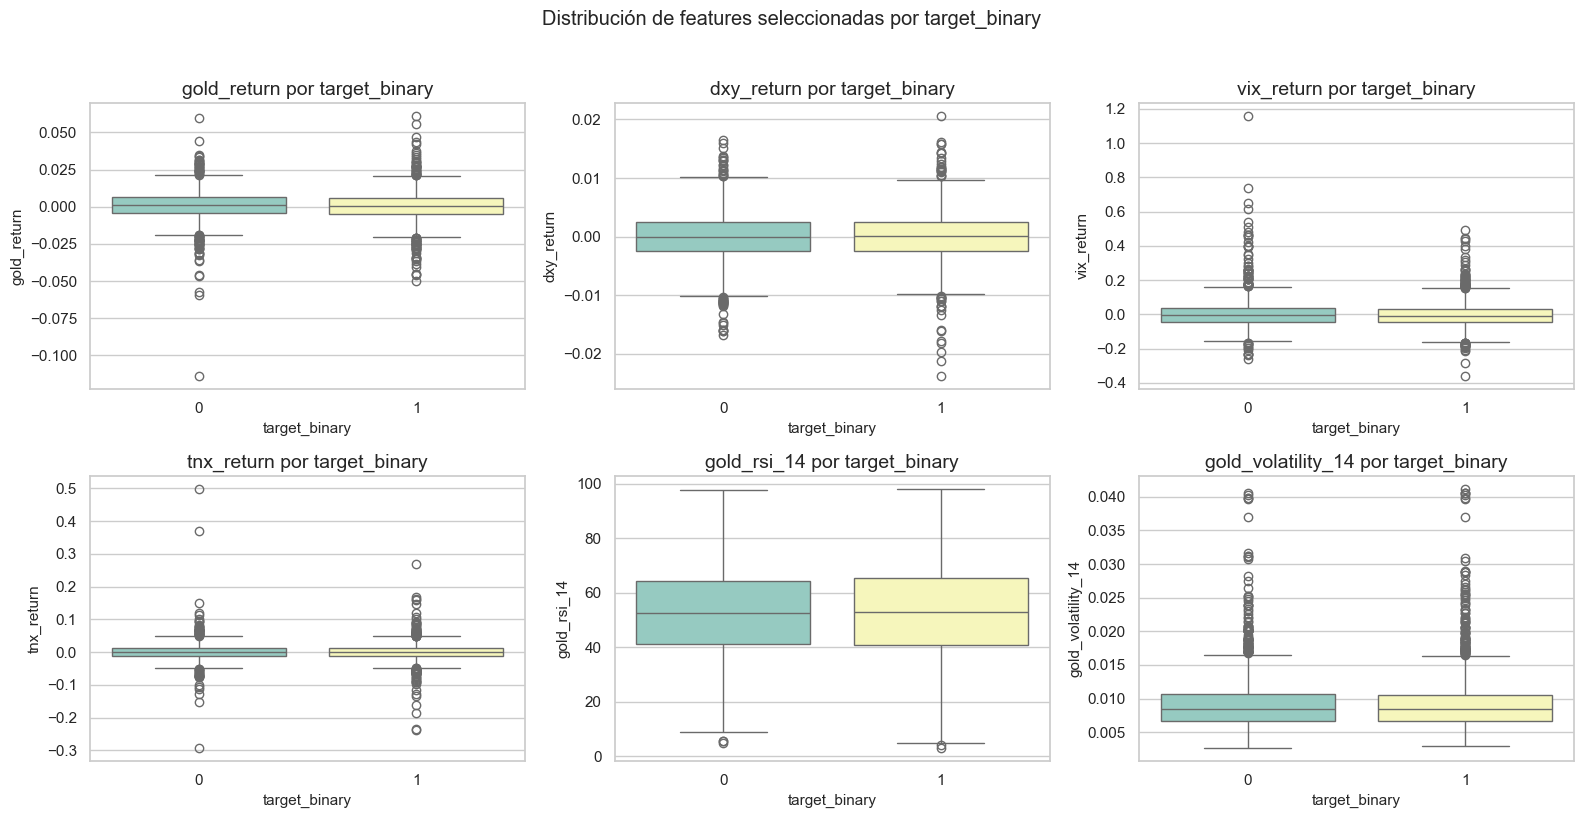

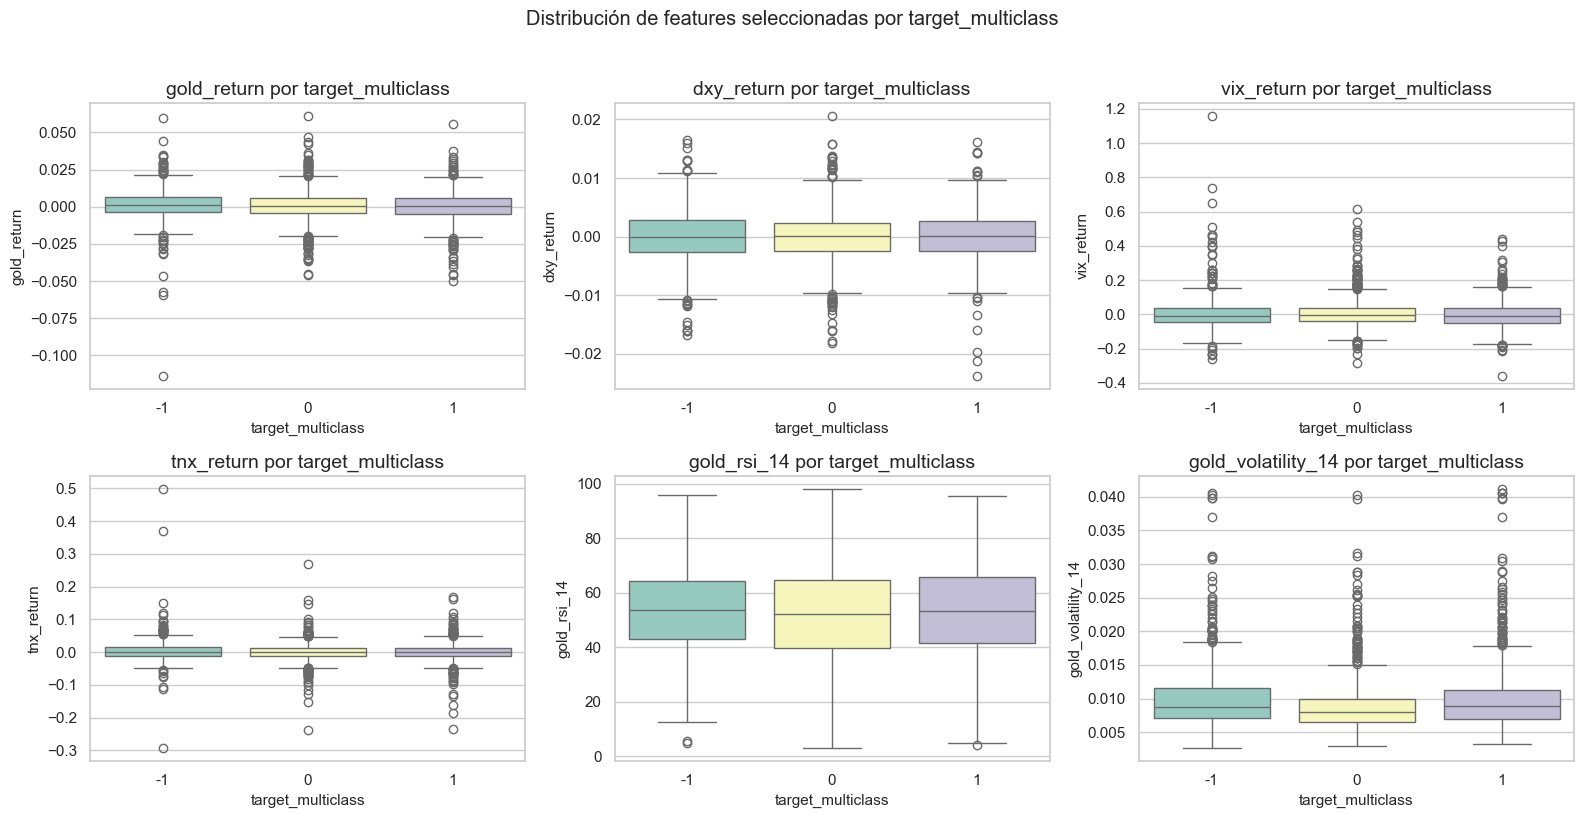

In [48]:
# Selección de features con interpretación financiera directa.
selected_features_for_target = [
    "gold_return",
    "dxy_return",
    "vix_return",
    "tnx_return",
    "gold_rsi_14",
    "gold_volatility_14",
]
selected_features_for_target = [column for column in selected_features_for_target if column in gold_df.columns]

for target in target_columns:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for index, column in enumerate(selected_features_for_target):
        sns.boxplot(data=gold_df, x=target, y=column, ax=axes[index], palette="Set3")
        axes[index].set_title(f"{column} por {target}")
        axes[index].set_xlabel(target)
        axes[index].set_ylabel(column)

    for empty_axis in axes[len(selected_features_for_target):]:
        empty_axis.set_visible(False)

    plt.suptitle(f"Distribución de features seleccionadas por {target}", y=1.02)
    plt.tight_layout()
    plt.show()

## 13. Matriz de correlación entre features

La correlación entre predictores permite detectar redundancias y multicolinealidad. Esto es especialmente útil para modelos lineales, interpretabilidad y selección de variables, aunque modelos basados en árboles pueden tolerar mejor variables correlacionadas.

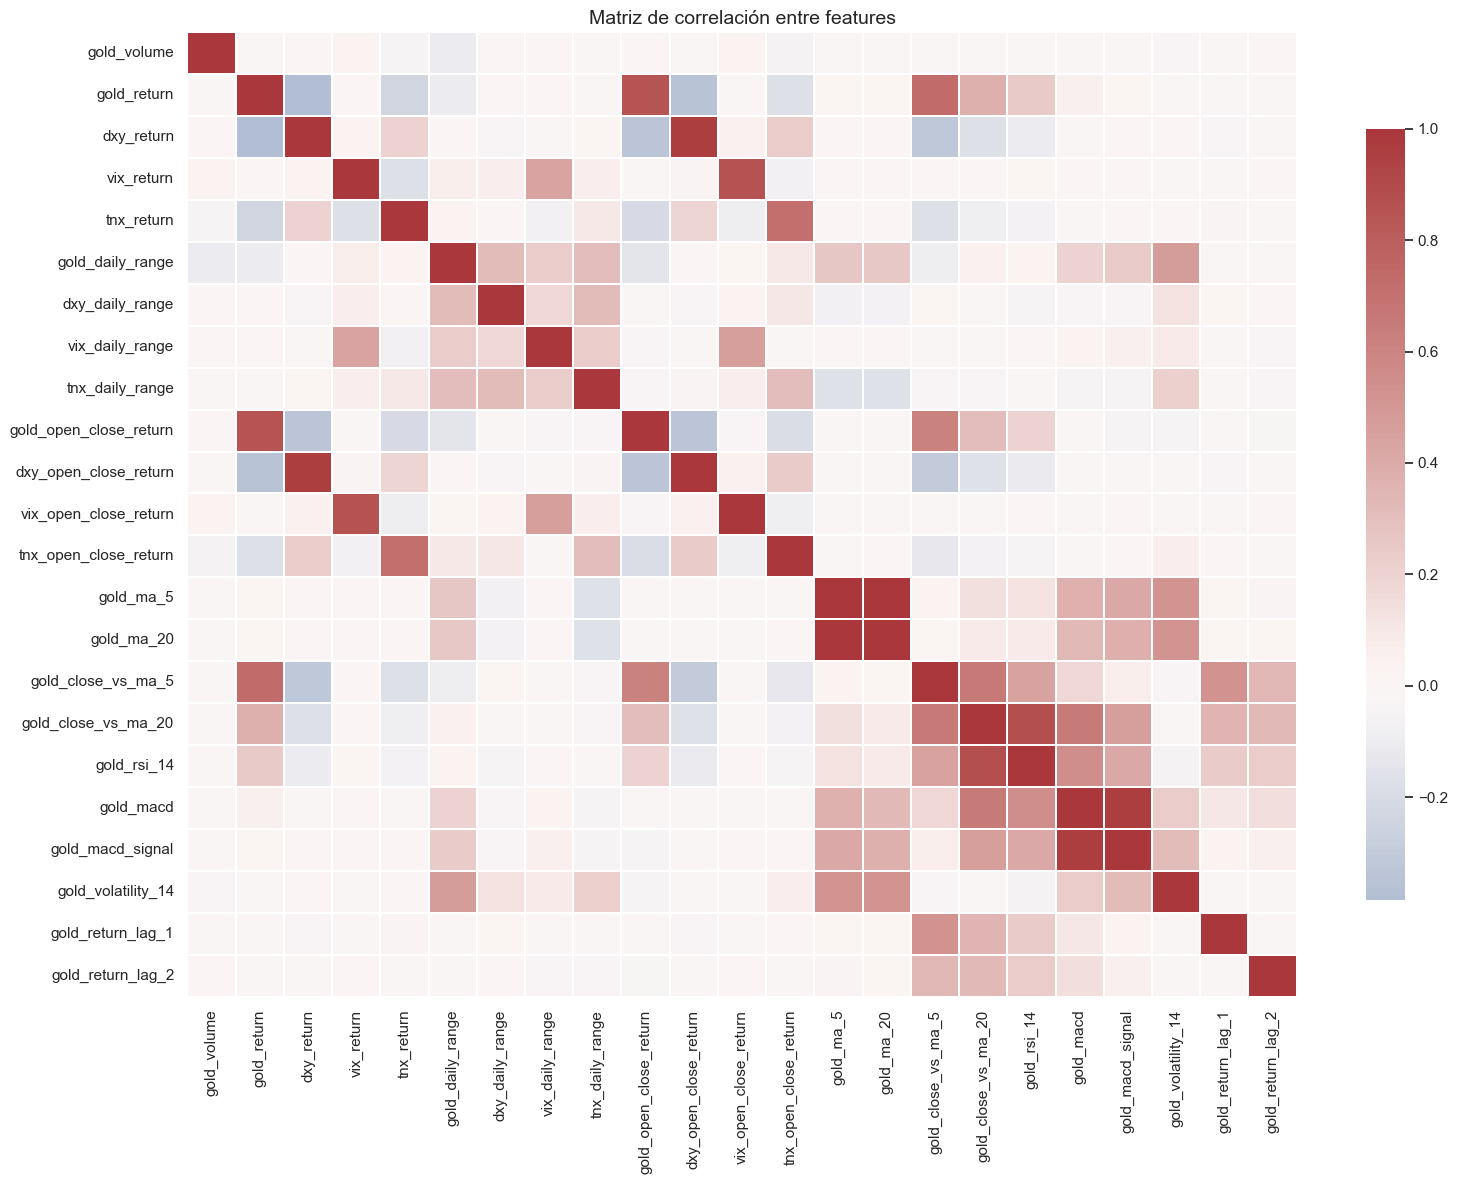

,feature_1,feature_2,correlation,abs_correlation
313,gold_ma_5,gold_ma_20,0.9985,0.9985
56,dxy_return,dxy_open_close_return,0.9584,0.9584
433,gold_macd,gold_macd_signal,0.9581,0.9581
385,gold_close_vs_ma_20,gold_rsi_14,0.8729,0.8729
80,vix_return,vix_open_close_return,0.8594,0.8594
32,gold_return,gold_open_close_return,0.8521,0.8521


In [49]:
# Correlación entre features numéricas.
feature_correlation = gold_df[feature_columns].corr(method="pearson")

plt.figure(figsize=(16, 12))
sns.heatmap(
    feature_correlation,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de correlación entre features")
plt.tight_layout()
plt.show()

# Pares de variables altamente correlacionadas.
correlation_pairs = (
    feature_correlation.where(np.triu(np.ones(feature_correlation.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

high_correlation_pairs = correlation_pairs.loc[correlation_pairs["correlation"].abs() >= 0.80]
high_correlation_pairs = high_correlation_pairs.assign(
    abs_correlation=high_correlation_pairs["correlation"].abs()
).sort_values("abs_correlation", ascending=False)

display(high_correlation_pairs.head(20))

## 14. Correlación de features con los targets

Medimos correlaciones lineales simples entre cada feature y los targets. Correlaciones bajas no descartan utilidad predictiva, pero sí indican que conviene probar modelos no lineales, interacciones y validación robusta.

,feature,target,correlation,abs_correlation
0,vix_return,target_binary,-0.0530,0.0530
1,vix_open_close_return,target_binary,-0.0455,0.0455
2,gold_return_lag_2,target_binary,0.0435,0.0435
3,vix_daily_range,target_binary,-0.0411,0.0411
4,gold_ma_20,target_binary,0.0348,0.0348
5,gold_ma_5,target_binary,0.0348,0.0348
6,gold_return,target_binary,-0.0345,0.0345
7,dxy_daily_range,target_binary,-0.0226,0.0226
8,tnx_daily_range,target_binary,-0.0216,0.0216
9,gold_macd_signal,target_binary,0.0215,0.0215


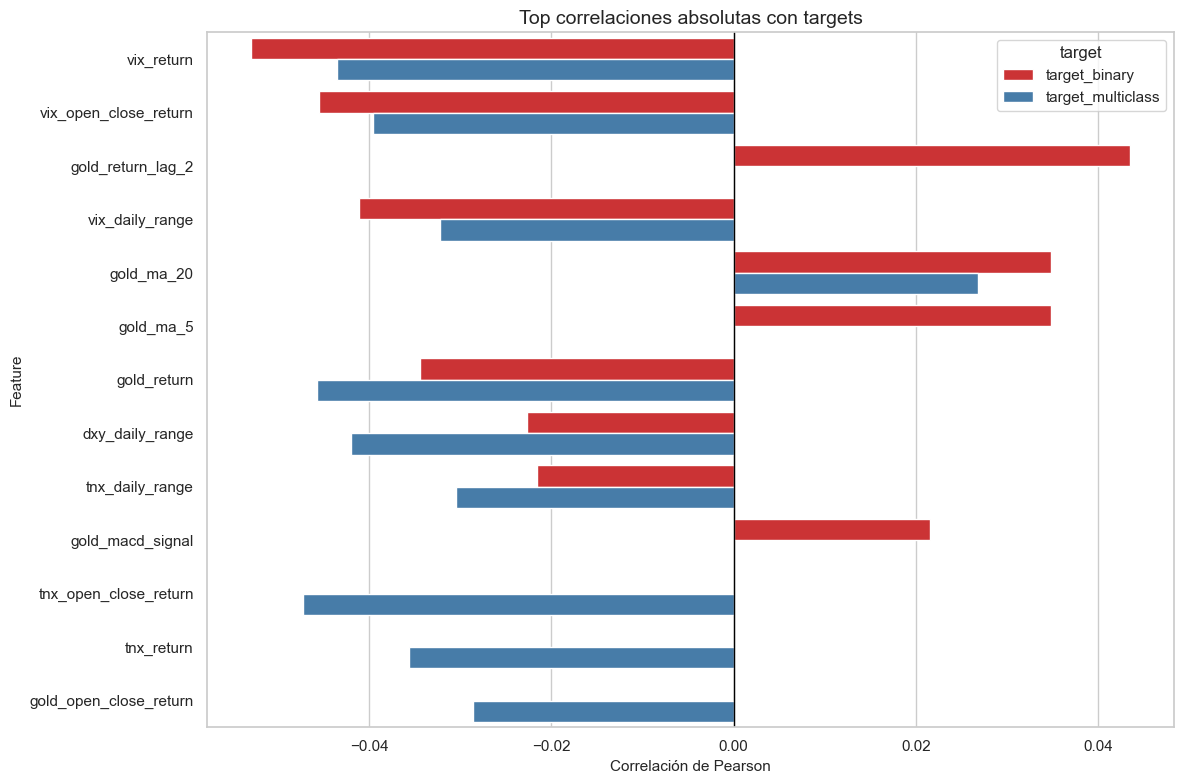

In [50]:
# Correlación de cada feature con los targets.
target_correlation_tables = []

for target in target_columns:
    target_corr = (
        gold_df[feature_columns + [target]]
        .corr(method="pearson")[target]
        .drop(target)
        .rename("correlation")
        .to_frame()
        .assign(abs_correlation=lambda table: table["correlation"].abs())
        .sort_values("abs_correlation", ascending=False)
    )
    target_corr.insert(0, "target", target)
    target_correlation_tables.append(target_corr.reset_index().rename(columns={"index": "feature"}))

all_target_correlations = pd.concat(target_correlation_tables, ignore_index=True)

display(all_target_correlations.groupby("target").head(10))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=all_target_correlations.groupby("target").head(10),
    x="correlation",
    y="feature",
    hue="target",
    palette="Set1",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top correlaciones absolutas con targets")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Revisión de volumen y posibles ceros

El volumen suele tener distribuciones muy asimétricas y puede contener ceros. Estos valores pueden ser válidos o indicar falta de negociación/captura; por eso conviene revisarlos antes de usar transformaciones como `log1p`.

,value
zero_volume_rows,36.0000
negative_volume_rows,0.0000
median_volume,213.0000
max_volume,386334.0000


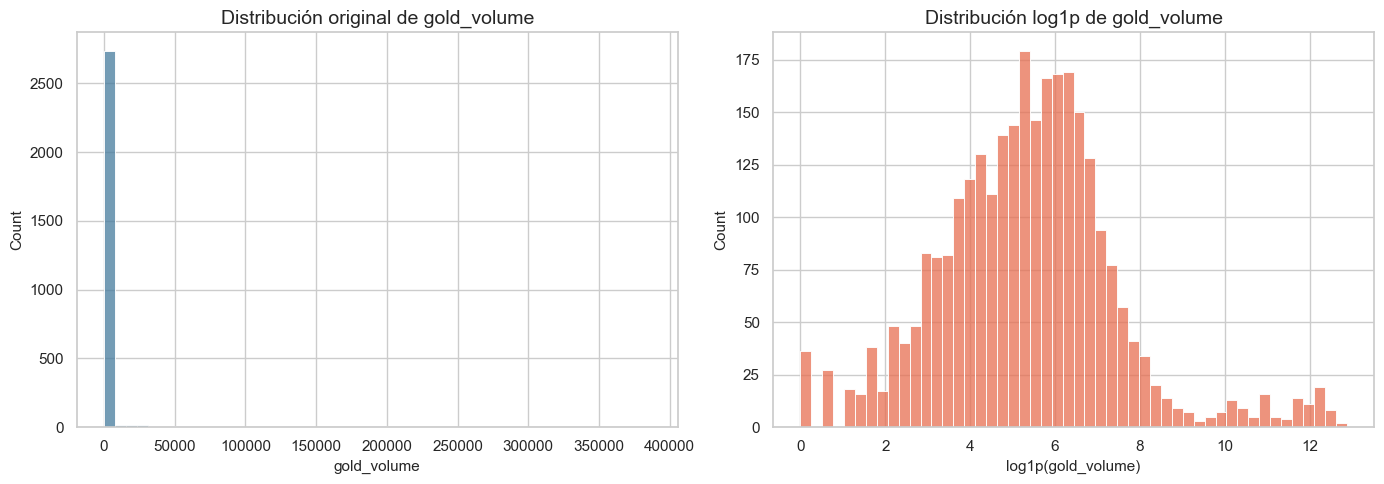

In [51]:
if "gold_volume" in gold_df.columns:
    volume_checks = {
        "zero_volume_rows": int((gold_df["gold_volume"] == 0).sum()),
        "negative_volume_rows": int((gold_df["gold_volume"] < 0).sum()),
        "median_volume": float(gold_df["gold_volume"].median()),
        "max_volume": float(gold_df["gold_volume"].max()),
    }
    display(pd.Series(volume_checks).to_frame("value"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(gold_df["gold_volume"], bins=50, ax=axes[0], color="#457b9d")
    axes[0].set_title("Distribución original de gold_volume")

    sns.histplot(np.log1p(gold_df["gold_volume"]), bins=50, ax=axes[1], color="#e76f51")
    axes[1].set_title("Distribución log1p de gold_volume")
    axes[1].set_xlabel("log1p(gold_volume)")

    plt.tight_layout()
    plt.show()
else:
    print("No existe la columna gold_volume en el dataset.")

## 16. Análisis temporal del target

Revisamos cómo evoluciona la proporción de clases en el tiempo. Si la distribución del target cambia por año, el modelo puede sufrir degradación por cambio de régimen y la validación cronológica se vuelve aún más importante.

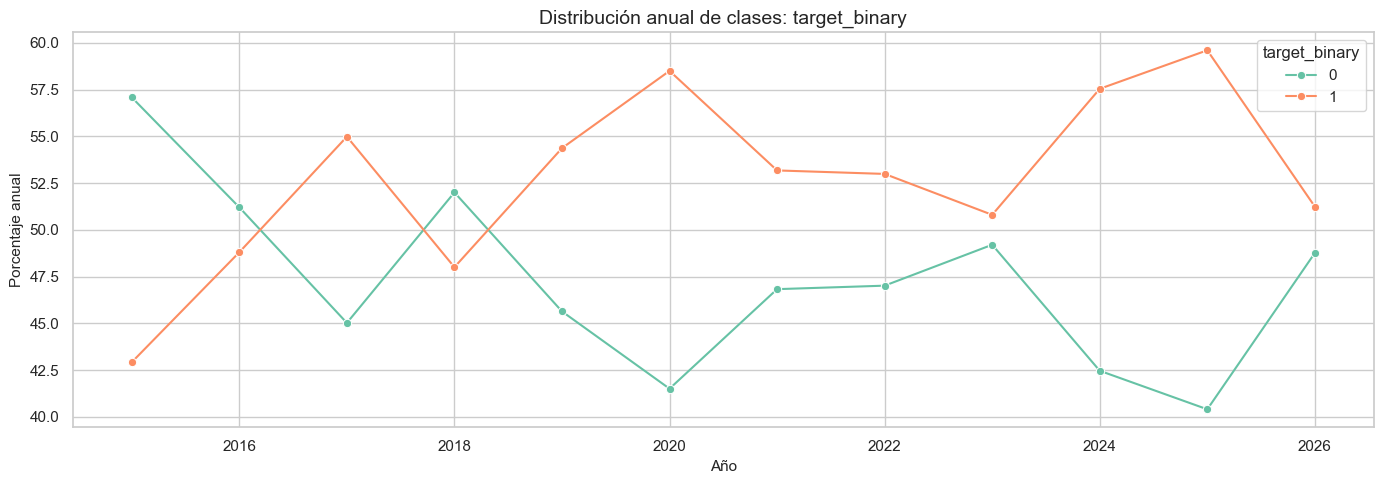

target_binary,0,1
year,,
2015,57.0800,42.9200
2016,51.2000,48.8000
2017,45.0200,54.9800
2018,52.0000,48.0000
2019,45.6300,54.3700
2020,41.5000,58.5000
2021,46.8300,53.1700
2022,47.0100,52.9900
2023,49.2000,50.8000


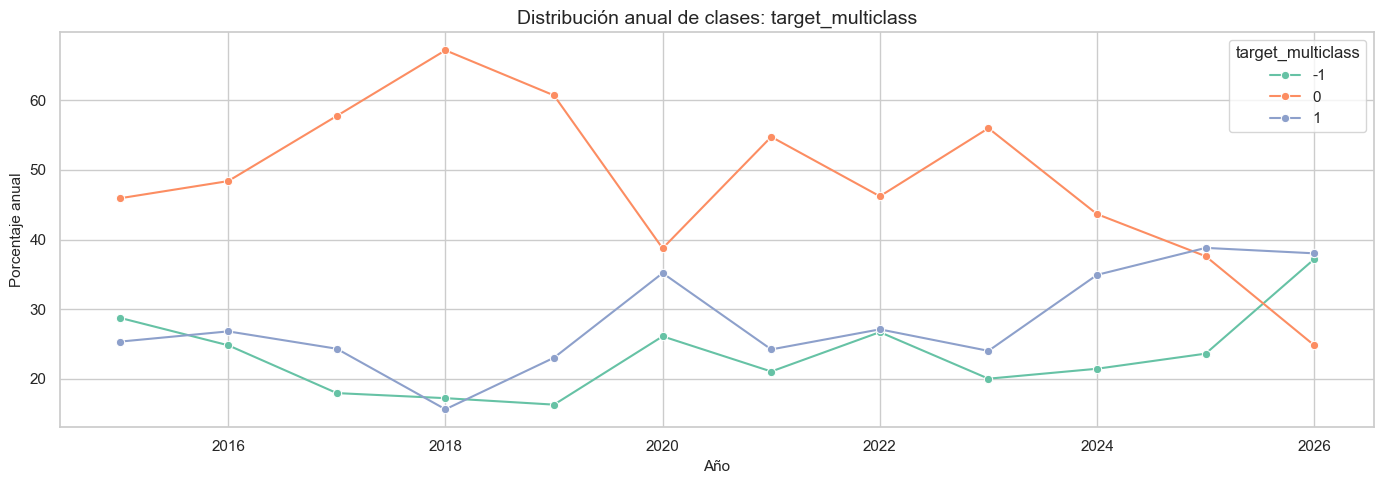

target_multiclass,-1,0,1
year,,,
2015,28.7600,45.9200,25.3200
2016,24.8000,48.4000,26.8000
2017,17.9300,57.7700,24.3000
2018,17.2000,67.2000,15.6000
2019,16.2700,60.7100,23.0200
2020,26.0900,38.7400,35.1800
2021,21.0300,54.7600,24.2100
2022,26.6900,46.2200,27.0900
2023,20.0000,56.0000,24.0000


In [52]:
# Agregamos año para analizar estabilidad temporal del target.
gold_df_with_year = gold_df.copy()
gold_df_with_year["year"] = gold_df_with_year["Date"].dt.year

for target in target_columns:
    yearly_target_distribution = (
        gold_df_with_year
        .groupby("year")[target]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percentage")
        .reset_index()
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(
        data=yearly_target_distribution,
        x="year",
        y="percentage",
        hue=target,
        marker="o",
        palette="Set2",
    )
    plt.title(f"Distribución anual de clases: {target}")
    plt.ylabel("Porcentaje anual")
    plt.xlabel("Año")
    plt.legend(title=target)
    plt.tight_layout()
    plt.show()

    display(yearly_target_distribution.pivot(index="year", columns=target, values="percentage").round(2))

## 17. Recomendaciones de preparación para ML

Sintetizamos señales del EDA en decisiones prácticas para el pipeline: validación, escalado, tratamiento de outliers, transformaciones y variables redundantes. Esta celda genera tablas que ayudan a convertir el an?lisis en tareas accionables.

In [53]:
# Tabla compacta de riesgos y acciones recomendadas.
ml_recommendations = pd.DataFrame([
    {
        "area": "Validación",
        "finding": "Dataset temporal con fechas ordenadas",
        "recommendation": "Usar split cronológico o TimeSeriesSplit; evitar train_test_split aleatorio como evaluación principal.",
    },
    {
        "area": "Nulos",
        "finding": f"Total de nulos detectados: {int(gold_df.isna().sum().sum())}",
        "recommendation": "Mantener un chequeo de nulos en el pipeline para datos futuros, aunque el histórico actual esté completo.",
    },
    {
        "area": "Targets",
        "finding": "target_binary balanceado; target_multiclass con clase neutral dominante",
        "recommendation": "Reportar métricas por clase: F1 macro, balanced accuracy y matriz de confusión temporal.",
    },
    {
        "area": "Outliers",
        "finding": "Volumen, volatilidad, retornos y rangos presentan valores extremos",
        "recommendation": "No eliminar automáticamente; probar winsorización, RobustScaler o transformaciones logarítmicas según modelo.",
    },
    {
        "area": "Correlaciones",
        "finding": "Correlaciones lineales bajas con targets y algunas features redundantes entre s?",
        "recommendation": "Probar modelos no lineales y revisar importancia de variables con validación temporal y permutation importance.",
    },
    {
        "area": "Leakage",
        "finding": "Existen features del mismo día y lags",
        "recommendation": "Confirmar cómo se construyó cada target para asegurar que ninguna feature use información posterior al momento de predicción.",
    },
])

display(ml_recommendations)

,area,finding,recommendation
0,Validación,Dataset temporal con fechas ordenadas,Usar split cronológico o TimeSeriesSplit; evit...
1,Nulos,Total de nulos detectados: 0,Mantener un chequeo de nulos en el pipeline pa...
2,Targets,target_binary balanceado; target_multiclass co...,"Reportar métricas por clase: F1 macro, balance..."
3,Outliers,"Volumen, volatilidad, retornos y rangos presen...",No eliminar automáticamente; probar winsorizac...
4,Correlaciones,Correlaciones lineales bajas con targets y alg...,Probar modelos no lineales y revisar importanc...
5,Leakage,Existen features del mismo día y lags,Confirmar cómo se construyó cada target para a...


## Takeaways

1. **Calidad base sálida:** el archivo analizado no presenta nulos ni duplicados exactos, y la columna temporal está ordenada. Esto reduce fricción para modelado, aunque conviene mantener validaciones automáticas para futuros datos.

2. **Targets razonablemente utilizables:** `target_binary` está bastante equilibrado, mientras que `target_multiclass` tiene una clase neutral dominante. Para clasificación multiclase, las métricas macro y por clase serán más informativas que accuracy simple.

3. **Outliers financieramente relevantes:** los valores extremos detectados en volumen, volatilidad, retornos y rangos probablemente contienen información de shocks de mercado. La recomendación profesional es analizarlos y tratarlos con técnicas robustas, no borrarlos de forma automática.

4. **Señal lineal limitada:** las correlaciones individuales con los targets son bajas. Esto sugiere que modelos como Random Forest, Gradient Boosting, XGBoost o enfoques con interacciones pueden ser más adecuados que depender solo de modelos lineales simples.

5. **Validación temporal obligatoria:** por tratarse de datos financieros, la evaluación debe respetar el orden cronológico. Una validación aleatoria puede sobreestimar el rendimiento y no representar bien el uso real del modelo.

6. **Próximo paso recomendado:** confirmar la definición exacta de `target_binary` y `target_multiclass`, revisar posible leakage temporal y construir un pipeline de preprocessing con escalado robusto, transformación de volumen y evaluación cronológica.